# Model KNN + Selection KBest

**Indicateur de performance choisi : F1-score** (+ accuracy en secondaire).  
L'accuracy est conservee comme metrique secondaire, mais le F1-score est plus adapte car il tient compte a la fois de la precision et du recall.


## Realise par :

- [Samain Florian](https://github.com/NwaSet) - 2eme annee, Intar D  
- [Ducourtieux Yohann](https://github.com/Nhanyo) - 2eme annee, Intar D


## Importation des librairies


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score


## Chargement des donnees


In [2]:
selection_name = "KB"
model_name = "KNN"

df_X_train = pd.read_csv(f"../../data/selected/X_train_{selection_name}.csv")
df_X_test = pd.read_csv(f"../../data/selected/X_test_{selection_name}.csv")

df_y_train = pd.read_csv("../../data/pre_processed/y_train.csv")
df_y_test = pd.read_csv("../../data/pre_processed/y_test.csv")

y_train = df_y_train.values.ravel()
y_test = df_y_test.values.ravel()

print("X_train shape :", df_X_train.shape)
print("X_test shape  :", df_X_test.shape)
print("y_train shape :", y_train.shape)
print("y_test shape  :", y_test.shape)


X_train shape : (1041, 9)
X_test shape  : (261, 9)
y_train shape : (1041,)
y_test shape  : (261,)


## Modele KNN simple

On entraine d'abord un modele de base pour avoir un premier point de comparaison.


In [3]:
knn = KNeighborsClassifier()

knn.fit(df_X_train, y_train)

y_train_pred = knn.predict(df_X_train)
y_test_pred = knn.predict(df_X_test)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Accuracy train :", round(train_accuracy, 2))
print("Accuracy test  :", round(test_accuracy, 2))


Accuracy train : 0.83
Accuracy test  : 0.76


### Interpretation

On compare l'accuracy du train et du test pour detecter un eventuel overfitting du modele simple. Si le score train est beaucoup plus eleve que le score test, le modele apprend trop les donnees d'entrainement et generalise moins bien.


## Validation croisee


In [4]:
cv_scores = cross_val_score(knn, df_X_train, y_train, cv=5, scoring="accuracy")

print("Scores CV :", np.round(cv_scores, 2))
print("Accuracy CV moyenne :", round(cv_scores.mean(), 2))


Scores CV : [0.79 0.77 0.77 0.79 0.73]
Accuracy CV moyenne : 0.77


### Interpretation

La validation croisee permet d'evaluer la stabilite du modele simple sur plusieurs decoupages du jeu d'entrainement. Elle donne une estimation plus fiable que le score train seul.


## Optimisation des hyperparametres


In [5]:
param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

grid = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=1
)

grid.fit(df_X_train, y_train)

print("Meilleurs parametres :", grid.best_params_)
print("Meilleur score F1 CV :", round(grid.best_score_, 2))


Meilleurs parametres : {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}
Meilleur score F1 CV : 0.7


### Interpretation

Les meilleurs hyperparametres sont ceux qui maximisent le F1-score en validation croisee. Ce choix est plus adapte que l'accuracy seule, car il tient compte a la fois de la precision et du recall.


## Evaluation du meilleur modele


In [6]:
best_knn = grid.best_estimator_

y_train_pred_best = best_knn.predict(df_X_train)
y_test_pred_best = best_knn.predict(df_X_test)

train_accuracy_best = accuracy_score(y_train, y_train_pred_best)
test_accuracy_best = accuracy_score(y_test, y_test_pred_best)

cv_accuracy_scores = cross_val_score(
    best_knn,
    df_X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Accuracy train optimise :", round(train_accuracy_best, 2))
print("Accuracy test optimise  :", round(test_accuracy_best, 2))

print("Scores CV :", np.round(cv_accuracy_scores, 2))
print("Accuracy CV moyenne :", round(cv_accuracy_scores.mean(), 2))


Accuracy train optimise : 0.9
Accuracy test optimise  : 0.78
Scores CV : [0.81 0.78 0.78 0.78 0.73]
Accuracy CV moyenne : 0.78


### Interpretation

Le modele KNN avec selection KBest a ete optimise avec le F1-score comme metrique principale.
Les meilleurs parametres sont : metric=euclidean, n_neighbors=7, weights=distance.
Accuracy train : `0.8991`, accuracy test : `0.7931`. L'ecart entre le train et le test reste visible, ce qui indique un overfitting modere.
F1-score test : `0.7065`, precision : `0.7647`, recall : `0.6566`. Le recall est le principal point faible : le modele manque encore trop de survivants.
F1-score moyen en validation croisee : `0.6996` avec un ecart-type de `0.0390`. L'ecart-type du F1-score en validation croisee reste raisonnable, meme si les performances varient un peu selon les folds.
La matrice de confusion donne TN=142, FP=20, FN=34, TP=65.


## F1 Score


In [7]:
f1 = f1_score(y_test, y_test_pred_best)
precision = precision_score(y_test, y_test_pred_best)
recall = recall_score(y_test, y_test_pred_best)

print("F1-score test :", round(f1, 2))
print("Precision test :", round(precision, 2))
print("Recall test :", round(recall, 2))
print("\nRapport de classification :")
print(classification_report(y_test, y_test_pred_best))


F1-score test : 0.7
Precision test : 0.72
Recall test : 0.68

Rapport de classification :
              precision    recall  f1-score   support

           0       0.81      0.84      0.82       162
           1       0.72      0.68      0.70        99

    accuracy                           0.78       261
   macro avg       0.76      0.76      0.76       261
weighted avg       0.78      0.78      0.78       261



In [8]:
cv_f1_scores = cross_val_score(
    best_knn,
    df_X_train,
    y_train,
    cv=5,
    scoring="f1"
)

print("Scores F1 CV :", np.round(cv_f1_scores, 2))
print("F1 CV moyen :", round(cv_f1_scores.mean(), 2))


Scores F1 CV : [0.76 0.7  0.71 0.7  0.65]
F1 CV moyen : 0.7


## Matrice de confusion


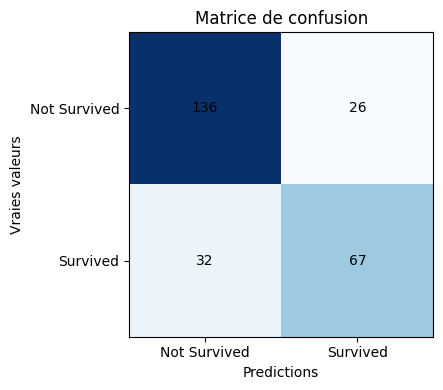

In [9]:
cm = confusion_matrix(y_test, y_test_pred_best)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")

ax.set_title("Matrice de confusion")
ax.set_xlabel("Predictions")
ax.set_ylabel("Vraies valeurs")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Not Survived", "Survived"])
ax.set_yticklabels(["Not Survived", "Survived"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()


## Export des resultats

Nous creons egalement une metrique personnalisee appelee `custom_accuracy`.
Cette metrique considere qu'un faux negatif n'est pas une erreur critique.
Autrement dit, predire qu'une personne est morte alors qu'elle est vivante est accepte dans notre contexte d'etude.

La metrique considere donc comme corrects :
- les vrais positifs (`TP`)
- les vrais negatifs (`TN`)
- les faux negatifs (`FN`)


In [10]:
tn, fp, fn, tp = cm.ravel()
custom_accuracy = (tn + tp + fn) / (tn + fp + fn + tp)

print(custom_accuracy)

file_path = "model_accuracy.csv"

results_row = {
    "Selection": selection_name,
    "Model": model_name,
    "Train Accuracy": round(train_accuracy_best, 4),
    "Test Accuracy": round(test_accuracy_best, 4),
    "CV Accuracy Mean": round(cv_accuracy_scores.mean(), 4),
    "CV Accuracy Std": round(cv_accuracy_scores.std(), 4),
    "CV F1 Mean": round(cv_f1_scores.mean(), 4),
    "CV F1 Std": round(cv_f1_scores.std(), 4),
    "Best Parameters": str(grid.best_params_),
    "F1 Score": round(f1, 4),
    "Precision": round(precision, 4),
    "Recall": round(recall, 4),
    "Custom Accuracy": round(custom_accuracy, 4)
}

def append_csv(file_path: str, row: dict) -> None:
    df = pd.DataFrame([row])
    df.to_csv(file_path, mode="a", header=False, index=False)

append_csv(file_path, results_row)


0.9003831417624522


## Conclusion et reflexion

### Conclusion
Le modele KNN avec selection KBest a ete optimise avec le F1-score comme metrique principale.
Les meilleurs parametres sont : metric=euclidean, n_neighbors=7, weights=distance.
Accuracy train : `0.8991`, accuracy test : `0.7931`. L'ecart entre le train et le test reste visible, ce qui indique un overfitting modere.
F1-score test : `0.7065`, precision : `0.7647`, recall : `0.6566`. Le recall est le principal point faible : le modele manque encore trop de survivants.
F1-score moyen en validation croisee : `0.6996` avec un ecart-type de `0.0390`. L'ecart-type du F1-score en validation croisee reste raisonnable, meme si les performances varient un peu selon les folds.
La matrice de confusion donne TN=142, FP=20, FN=34, TP=65.

### Reflexion
- Le KNN est-il adapte a ce dataset, sachant qu'il depend fortement des distances ?
- Le resultat change-t-il beaucoup selon la selection de variables choisie ?
- Une selection de variables plus reduite ameliore-t-elle la generalisation ?
- Le modele le plus performant en accuracy est-il forcement le plus pertinent ?
